# Exploratory Data Analysis for processing

## Imports

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parents[0]

In [2]:
pgcb_dataset = pd.read_csv(ROOT / "data/raw/PGCB_date_power_demand.csv")
economics_dataset = pd.read_csv(ROOT / "data/raw/economic_full_1.csv")
weather_dataset = pd.read_csv(ROOT / "data/raw/weather_data.csv", skiprows=3)

## PGCB_Data Set

In [3]:
pgcb_dataset.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [4]:
print(pgcb_dataset.info())
print("=" * 67)
print(pgcb_dataset.isna().mean()*100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              92650 non-null  object 
 1   generation_mw         92650 non-null  float64
 2   demand_mw             92650 non-null  int64  
 3   load_shedding         92650 non-null  int64  
 4   gas                   92650 non-null  int64  
 5   liquid_fuel           92650 non-null  int64  
 6   coal                  92650 non-null  int64  
 7   hydro                 92650 non-null  int64  
 8   solar                 70517 non-null  float64
 9   wind                  18676 non-null  float64
 10  india_bheramara_hvdc  92650 non-null  int64  
 11  india_tripura         92650 non-null  int64  
 12  india_adani           7338 non-null   float64
 13  nepal                 5351 non-null   float64
 14  remarks               6393 non-null   object 
dtypes: float64(5), int6

### Extarcting Train Data

In [5]:
pgcb_dataset['datetime'] = pd.to_datetime(pgcb_dataset['datetime'])
pgcb_dataset = pgcb_dataset.sort_values('datetime').reset_index(drop=True)

pgcb_train = pgcb_dataset[pgcb_dataset['datetime'].dt.year <= 2023].copy()

In [6]:
pgcb_dataset.demand_mw.describe()

count     92650.000000
mean       8819.646044
std        2772.150108
min           6.000000
25%        6812.250000
50%        8422.000000
75%       10633.000000
max      156050.000000
Name: demand_mw, dtype: float64

In [7]:
print(pgcb_train.shape)
print("=" * 67)
print("Null val %\n", pgcb_dataset.isna().mean()*100)

pgcb_df = pgcb_train.copy()

(79314, 15)
Null val %
 datetime                 0.000000
generation_mw            0.000000
demand_mw                0.000000
load_shedding            0.000000
gas                      0.000000
liquid_fuel              0.000000
coal                     0.000000
hydro                    0.000000
solar                   23.888829
wind                    79.842418
india_bheramara_hvdc     0.000000
india_tripura            0.000000
india_adani             92.079870
nepal                   94.224501
remarks                 93.099838
dtype: float64


In [8]:
pgcb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79314 entries, 0 to 79313
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              79314 non-null  datetime64[ns]
 1   generation_mw         79314 non-null  float64       
 2   demand_mw             79314 non-null  int64         
 3   load_shedding         79314 non-null  int64         
 4   gas                   79314 non-null  int64         
 5   liquid_fuel           79314 non-null  int64         
 6   coal                  79314 non-null  int64         
 7   hydro                 79314 non-null  int64         
 8   solar                 57181 non-null  float64       
 9   wind                  5340 non-null   float64       
 10  india_bheramara_hvdc  79314 non-null  int64         
 11  india_tripura         79314 non-null  int64         
 12  india_adani           0 non-null      float64       
 13  nepal                

In [9]:
print(pgcb_df.remarks.value_counts())
pgcb_df = pgcb_df.drop('remarks',axis = 1)

remarks
Day_Peak        2778
Evening_Peak    2588
Name: count, dtype: int64


### Timestamps

#### Duplicates

In [10]:
print(pgcb_df.duplicated(subset='datetime').sum())
pgcb_df[pgcb_df.duplicated(subset='datetime', keep=False)].sort_values('datetime').head(10)

418


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
76,2015-04-22 21:00:00,5811.0,5811,0,4158,1021,162,30,NaN,NaN,440,0,NaN,NaN
77,2015-04-22 21:00:00,5368.0,5368,0,4184,552,160,30,NaN,NaN,442,0,NaN,NaN
79,2015-04-23 00:00:00,5726.0,5726,0,4199,790,158,46,NaN,NaN,433,0,NaN,NaN
80,2015-04-23 00:00:00,3976.0,3976,0,3116,230,158,30,NaN,NaN,442,0,NaN,NaN
158,2015-04-27 00:00:00,5236.0,5236,0,4417,159,162,46,NaN,NaN,452,0,NaN,NaN
159,2015-04-27 00:00:00,4800.0,4800,0,3954,117,166,46,NaN,NaN,458,0,NaN,NaN
160,2015-04-27 00:00:00,5459.0,5459,0,4457,363,148,45,NaN,NaN,458,0,NaN,NaN
238,2015-04-30 00:00:00,5809.0,5809,0,4901,257,154,46,NaN,NaN,451,0,NaN,NaN
239,2015-04-30 00:00:00,6065.0,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN
240,2015-04-30 00:00:00,6889.0,6889,0,4698,1540,157,42,NaN,NaN,452,0,NaN,NaN


In [11]:
pgcb_df = pgcb_df.groupby('datetime').mean().reset_index()
print(pgcb_df.duplicated(subset='datetime').sum())
print(pgcb_df.shape)

0
(78896, 14)


#### Checking irregular timestamps

In [12]:
print("hour" , pgcb_df['datetime'].dt.hour.unique())
print("minutes" , pgcb_df['datetime'].dt.minute.unique())
print("seconds" , pgcb_df['datetime'].dt.second.unique())

hour [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
minutes [ 0 30]
seconds [0]


In [13]:
print((pgcb_df['datetime'].dt.minute != 0).sum())
pgcb_df[pgcb_df['datetime'].dt.minute != 0].head(10)

3640


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
18,2015-04-19 17:30:00,6299.0,6299.0,0.0,4056.0,1602.0,156.0,42.0,NaN,NaN,443.0,0.0,NaN,NaN
20,2015-04-19 18:30:00,6933.0,6933.0,0.0,4423.0,1862.0,159.0,45.0,NaN,NaN,444.0,0.0,NaN,NaN
46,2015-04-21 17:30:00,6698.0,6698.0,0.0,4184.0,1894.0,145.0,45.0,NaN,NaN,430.0,0.0,NaN,NaN
48,2015-04-21 18:30:00,7409.0,7409.0,0.0,4474.0,2289.0,146.0,70.0,NaN,NaN,430.0,0.0,NaN,NaN
71,2015-04-22 17:30:00,6195.0,6195.0,0.0,4185.0,1372.0,153.0,45.0,NaN,NaN,440.0,0.0,NaN,NaN
73,2015-04-22 18:30:00,6689.0,6689.0,0.0,4399.0,1648.0,158.0,44.0,NaN,NaN,440.0,0.0,NaN,NaN
96,2015-04-23 17:30:00,6141.0,6141.0,0.0,4329.0,1187.0,152.0,40.0,NaN,NaN,433.0,0.0,NaN,NaN
98,2015-04-23 18:30:00,6710.0,6710.0,0.0,4444.0,1635.0,158.0,40.0,NaN,NaN,433.0,0.0,NaN,NaN
122,2015-04-24 17:30:00,5518.0,5518.0,0.0,4123.0,763.0,157.0,30.0,NaN,NaN,445.0,0.0,NaN,NaN
124,2015-04-24 18:30:00,6678.0,6678.0,0.0,4486.0,1545.0,157.0,44.0,NaN,NaN,446.0,0.0,NaN,NaN


In [14]:
full_range = pd.date_range(pgcb_df['datetime'].min(), 
                           pgcb_df['datetime'].max(), freq='h')

missing_ts = full_range.difference(pgcb_df['datetime'])
print(f"Missing timestamps: {len(missing_ts)}")

Missing timestamps: 1040


#### Fixing half hourly timestamps

In [15]:
df = pgcb_df.sort_values('datetime').copy()

num_cols = df.select_dtypes(include='number').columns

df_00 = df[df['datetime'].dt.minute == 0].copy()
df_30 = df[df['datetime'].dt.minute == 30].copy()

df_30['datetime'] = df_30['datetime'].dt.floor('h')

common = df_30['datetime'].isin(df_00['datetime'])
case1_30 = df_30[common].set_index('datetime')
case1_00 = df_00[df_00['datetime'].isin(case1_30.index)].set_index('datetime')

merged1 = ((case1_00[num_cols] + case1_30[num_cols]) / 2).reset_index()

case2_30 = df_30[~common].copy()
case2_30['prev'] = case2_30['datetime'] - pd.Timedelta(hours=1)
case2_prev = df_00[df_00['datetime'].isin(case2_30['prev'])].set_index('datetime')
case2_30 = case2_30.set_index('prev')

merged2 = (0.7 * case2_prev[num_cols] + 0.3 * case2_30[num_cols])
merged2 = merged2.reset_index(drop=True)
merged2['datetime'] = case2_30.index.values

used = pd.concat([merged1['datetime'], merged2['datetime']])
remaining = df_00[~df_00['datetime'].isin(used)]

pgcb_df = pd.concat([remaining, merged1, merged2], ignore_index=True).sort_values('datetime').reset_index(drop=True)

print((pgcb_df['datetime'].dt.minute == 30).sum())
print(pgcb_df.shape)

0
(75256, 14)


#### Missing timestamps

In [16]:
full_range = pd.date_range(pgcb_df['datetime'].min(), 
                           pgcb_df['datetime'].max(), freq='h')

missing_ts = full_range.difference(pgcb_df['datetime'])
print(f"Missing timestamps: {len(missing_ts)}")

Missing timestamps: 1040


In [17]:
pgcb_df = pgcb_df.set_index('datetime')
pgcb_df = pgcb_df.reindex(full_range)
pgcb_df = pgcb_df.ffill()
pgcb_df = pgcb_df.reset_index().rename(columns={'index': 'datetime'})

print(pgcb_df.shape)
print(pgcb_df.isnull().sum().sum())

(76296, 14)
244554


### Outlier Detection and Imputation

#### Summary of data

In [18]:
pgcb_df.columns

Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal'],
      dtype='object')

In [19]:
source_cols = ['gas','liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc','india_tripura', 'india_adani', 'nepal']
pgcb_df[source_cols] = pgcb_df[source_cols].fillna(0)

In [20]:
pgcb_df[['demand_mw','generation_mw','load_shedding']].describe()

,demand_mw,generation_mw,load_shedding
count,76296.000000,7.629600e+04,76296.000000
mean,8304.671322,9.084129e+03,63.789176
std,2456.049329,2.335889e+05,454.661628
min,6.000000,7.300000e+01,0.000000
25%,6509.000000,6.511000e+03,0.000000
50%,7945.500000,7.941350e+03,0.000000
75%,9866.000000,9.826000e+03,0.000000
max,117000.000000,6.452650e+07,65359.000000


In [21]:
pgcb_df[source_cols].describe()

,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,76296.000000,7.629600e+04,76296.000000,76296.000000,76296.000000,76296.000000,76296.000000,76296.000000,76296.0,76296.0
mean,5108.841260,2.133512e+03,583.434502,97.499855,21.415727,0.352509,632.102670,97.230397,0.0,0.0
std,1173.618679,1.058773e+05,756.619214,69.629858,61.571783,2.488174,369.865982,47.249963,0.0,0.0
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
25%,4379.000000,7.550000e+02,150.000000,45.000000,0.000000,0.000000,459.000000,74.000000,0.0,0.0
50%,4984.000000,1.556000e+03,311.000000,80.000000,0.000000,0.000000,569.000000,102.000000,0.0,0.0
75%,5848.250000,2.482000e+03,666.000000,148.000000,5.900000,0.000000,896.250000,130.000000,0.0,0.0
max,74818.000000,2.922290e+07,25085.000000,5623.000000,2901.000000,243.000000,76292.000000,1234.000000,0.0,0.0


In [22]:
pgcb_df.drop(['india_adani','nepal'],axis=1)
source_cols.remove('india_adani')
source_cols.remove('nepal')

In [23]:
source_cols

['gas',
 'liquid_fuel',
 'coal',
 'hydro',
 'solar',
 'wind',
 'india_bheramara_hvdc',
 'india_tripura']

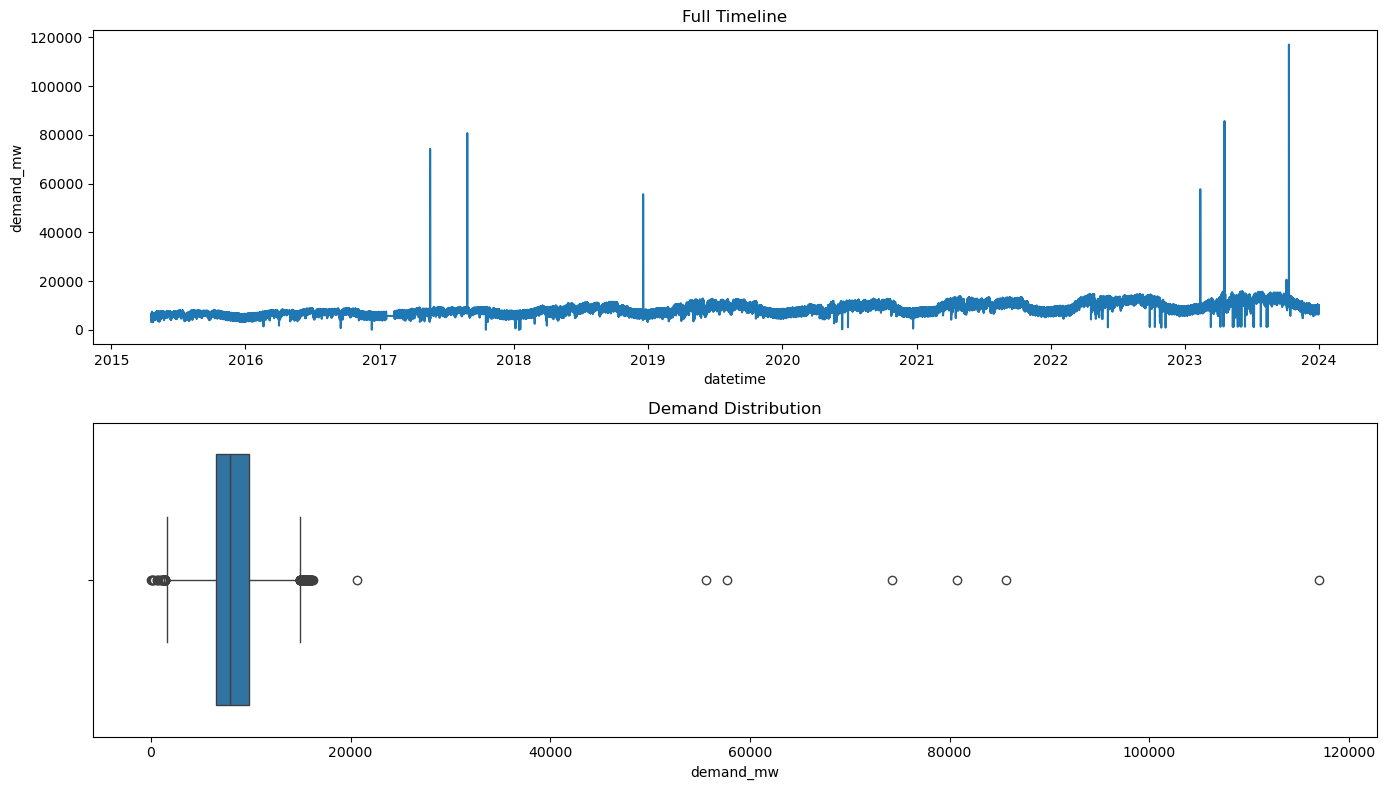

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sns.lineplot(x=pgcb_df['datetime'], y=pgcb_df['demand_mw'], ax=axes[0])
axes[0].set_title('Full Timeline')

sns.boxplot(x=pgcb_df['demand_mw'], ax=axes[1])
axes[1].set_title('Demand Distribution')

plt.tight_layout()
plt.show()

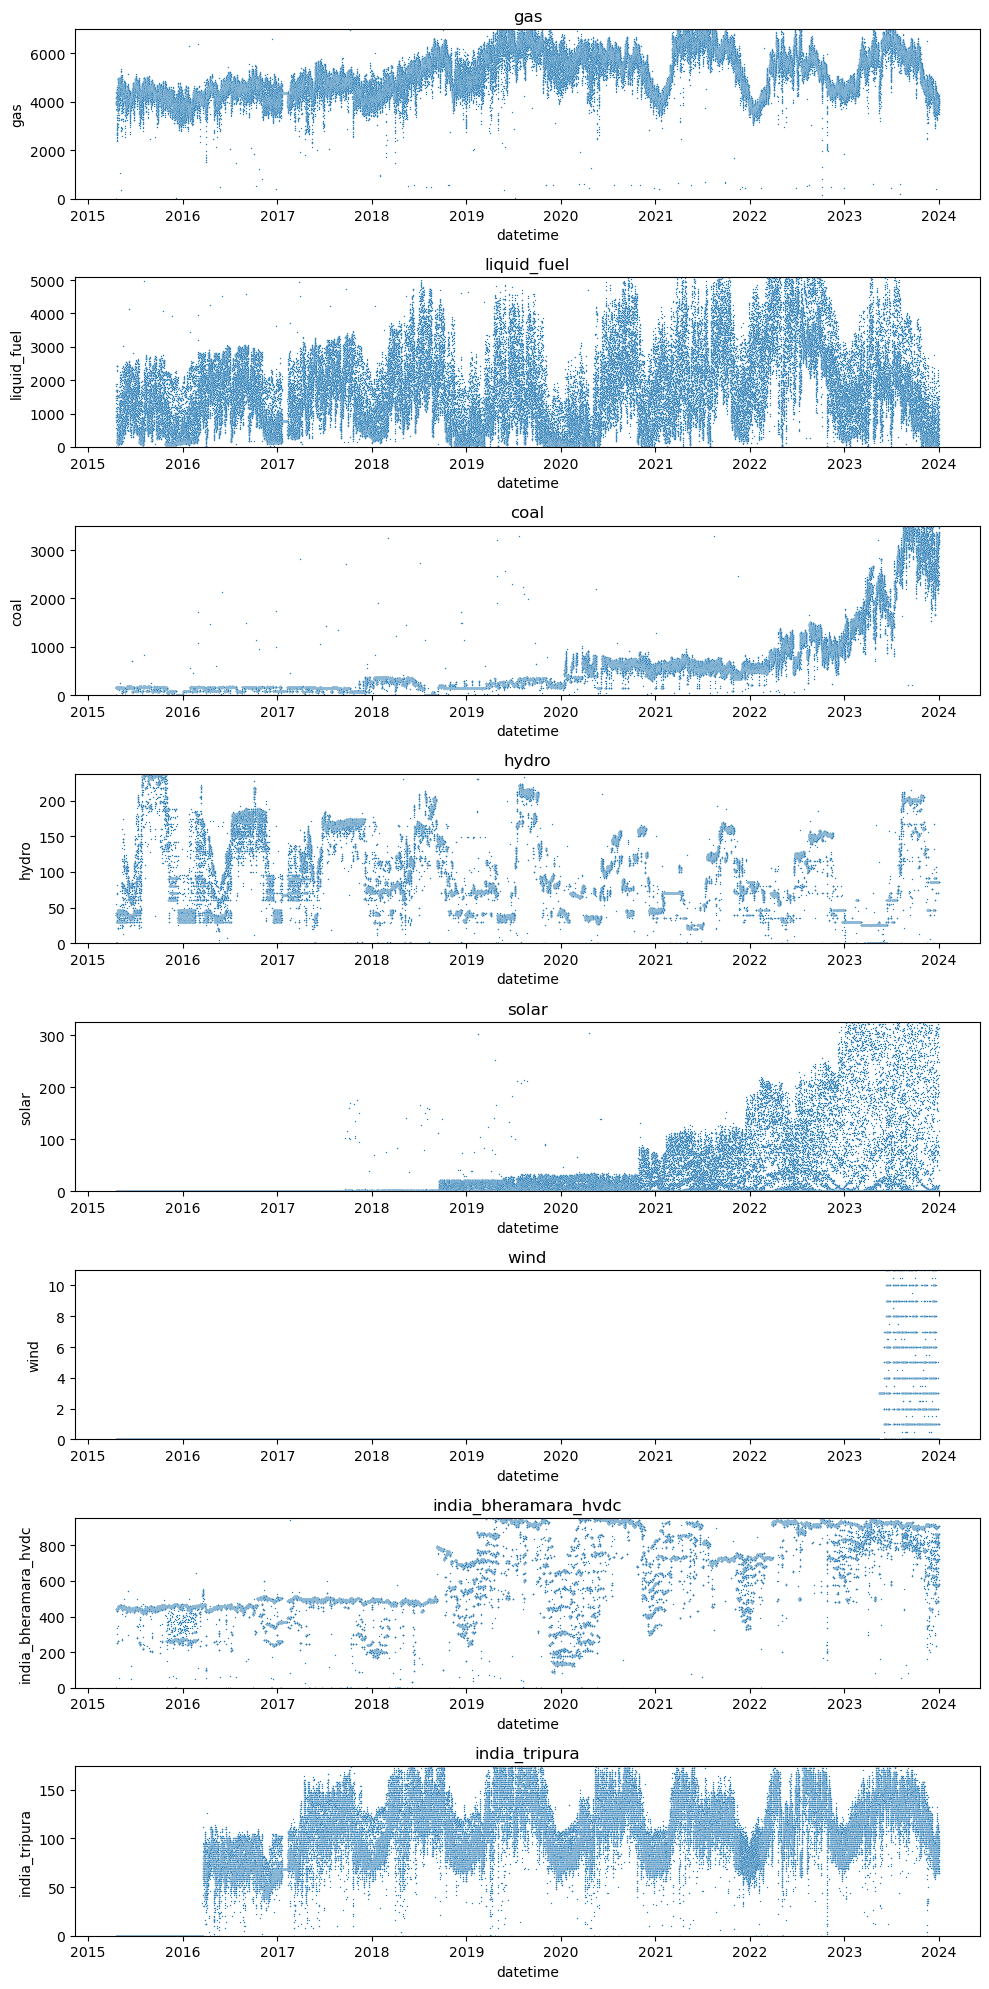

In [25]:
fig, axes = plt.subplots(8, 1, figsize=(10, 20))
axes = axes.flatten()

for i, col in enumerate(source_cols):
    sns.scatterplot(data=pgcb_df, x='datetime', y=col, ax=axes[i], s=1)
    axes[i].set_ylim(0, pgcb_df[col].quantile(0.99))
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#### Outlier flagging

In [26]:
pgcb_df['source_sum'] = pgcb_df[source_cols].sum(axis=1)

pgcb_df['source_demand_gap'] = pgcb_df['generation_mw'] - pgcb_df['source_sum']
print(pgcb_df['source_demand_gap'].describe())

count    7.629600e+04
mean     4.097404e+02
std      2.564581e+05
min     -2.922002e+07
25%     -1.400000e+01
50%     -7.000000e+00
75%     -1.000000e+00
max      6.452004e+07
Name: source_demand_gap, dtype: float64


In [27]:
(pgcb_df['source_sum'] == 0).sum()
#very few cols better to fill with forward/backward fill

np.int64(17)

##### Demand_mw

In [28]:
pgcb_cleaned = pgcb_df.copy()

target      = 'demand_mw'
early_cols  = ['gas', 'liquid_fuel', 'coal', 'hydro', 'india_bheramara_hvdc']
late_cols   = ['solar', 'wind', 'india_tripura']
source_cols = early_cols + late_cols

def rolling_mad_score(x, w):
    med = x.rolling(w, min_periods=1).median().shift(1)
    mad = (x - med).abs().rolling(w, min_periods=1).median().shift(1)
    return (x - med) / (mad + 1e-6)

# step 1: flag demand and generation
z_short  = rolling_mad_score(pgcb_df[target], 24)
z_long   = rolling_mad_score(pgcb_df[target], 24*7)
lag_diff = pgcb_df[target].diff().abs()
lag_med  = lag_diff.rolling(24, min_periods=1).median().shift(1)
jump     = lag_diff > 6 * (lag_med + 1e-6)
demand_flags = ((z_short.abs() > 6) & (z_long.abs() > 4)) | jump

z_gen_short = rolling_mad_score(pgcb_df['generation_mw'], 24)
z_gen_long  = rolling_mad_score(pgcb_df['generation_mw'], 24*7)
lag_diff_gen = pgcb_df['generation_mw'].diff().abs()
lag_med_gen  = lag_diff_gen.rolling(24, min_periods=1).median().shift(1)
jump_gen     = lag_diff_gen > 6 * (lag_med_gen + 1e-6)

gen_flags = ((z_gen_short.abs() > 6) & (z_gen_long.abs() > 4)) | jump_gen

ls_nonzero = pgcb_cleaned['load_shedding'][pgcb_cleaned['load_shedding'] > 0]

ls_q3  = ls_nonzero.quantile(0.75)
ls_iqr = ls_q3 - ls_nonzero.quantile(0.25)

ls_flags = pgcb_cleaned['load_shedding'] > ls_q3 + 3 * ls_iqr
print(f"ls flags: {ls_flags.sum()}")
print(f"ls flags: {ls_flags.sum()}")
print(f"demand flags:     {demand_flags.sum()}")
print(f"generation flags: {gen_flags.sum()}")

ls flags: 18
ls flags: 18
demand flags:     2182
generation flags: 2221


##### Imputing demand_mw

In [29]:
ls_clean = pgcb_cleaned['load_shedding'].copy()
ls_clean[ls_flags] = 0

source_sum       = pgcb_cleaned[source_cols].sum(axis=1)
gen_source_match = (pgcb_cleaned['generation_mw'] - source_sum).abs() <= 100
fallback         = pgcb_cleaned[target].rolling(24, min_periods=6).median().shift(1)

# case 1a - gen ok + ls ok
case1a = demand_flags & ~gen_flags & ~ls_flags
pgcb_cleaned.loc[case1a, target] = pgcb_cleaned.loc[case1a, 'generation_mw'] + ls_clean[case1a]

# case 1b - gen ok + ls bad → just gen
case1b = demand_flags & ~gen_flags & ls_flags
pgcb_cleaned.loc[case1b, target] = pgcb_cleaned.loc[case1b, 'generation_mw']

# case 2a - gen flagged but source_sum agrees + ls ok
case2a = demand_flags & gen_flags & gen_source_match & ~ls_flags
pgcb_cleaned.loc[case2a, target] = pgcb_cleaned.loc[case2a, 'generation_mw'] + ls_clean[case2a]

# case 2b - gen flagged but source_sum agrees + ls bad
case2b = demand_flags & gen_flags & gen_source_match & ls_flags
pgcb_cleaned.loc[case2b, target] = pgcb_cleaned.loc[case2b, 'generation_mw']

# case 3 - gen flagged + source_sum doesnt match
case3 = demand_flags & gen_flags & ~gen_source_match
pgcb_cleaned.loc[case3, target] = fallback[case3]

print(f"case1a:{case1a.sum()} case1b:{case1b.sum()} case2a:{case2a.sum()} case2b:{case2b.sum()} case3:{case3.sum()}")
print(f"min: {pgcb_cleaned[target].min():.0f}, max: {pgcb_cleaned[target].max():.0f}")

case1a:136 case1b:3 case2a:1944 case2b:0 case3:99
min: 1759, max: 16221


##### Sources

##### Fixing Blackouts cols(all source empty)

In [30]:
total_source = pgcb_cleaned[source_cols].sum(axis=1)
blackout     = (total_source == 0) & (pgcb_cleaned[target] > 0)
print(f"blackout rows: {blackout.sum()}")

# get reference sources — NaN out blackout rows then fill from neighbors
ref_sources = pgcb_cleaned[source_cols].copy()
ref_sources.loc[blackout] = np.nan
ref_sources = ref_sources.bfill().ffill()

# scale reference mix to match current demand
ref_total    = ref_sources.sum(axis=1)
scale_factor = pgcb_cleaned.loc[blackout, target] / (ref_total[blackout] + 1e-8)

for col in source_cols:
    pgcb_cleaned.loc[blackout, col] = ref_sources.loc[blackout, col] * scale_factor

# verify
remaining = (pgcb_cleaned[source_cols].sum(axis=1) == 0) & (pgcb_cleaned[target] > 0)
print(f"remaining blackouts: {remaining.sum()}")

blackout rows: 17
remaining blackouts: 0


In [31]:
pgcb_cleaned['source_sum']   = pgcb_cleaned[source_cols].sum(axis=1)

In [32]:
source_cols

['gas',
 'liquid_fuel',
 'coal',
 'hydro',
 'india_bheramara_hvdc',
 'solar',
 'wind',
 'india_tripura']

In [140]:
pgcb_cleaned[source_cols].describe()

,gas,liquid_fuel,coal,hydro,india_bheramara_hvdc,solar,wind,india_tripura
count,76296.000000,76296.000000,76296.000000,76296.000000,76296.000000,76296.000000,76296.000000,76296.000000
mean,5102.648921,1721.746218,581.446743,96.855366,629.879219,21.438022,0.352509,97.130729
std,909.893405,1208.531572,740.784626,59.618953,233.982836,60.633210,2.488174,46.378743
min,1475.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4380.750000,753.000000,150.000000,45.000000,459.000000,0.000000,0.000000,74.000000
50%,4987.000000,1554.000000,311.000000,80.000000,567.000000,0.000000,0.000000,102.000000
75%,5850.000000,2481.000000,665.000000,148.000000,896.000000,5.900000,0.000000,130.000000
max,9162.500000,8325.500000,7329.000000,1216.000000,3868.000000,1049.000000,243.000000,1234.000000


##### Flagging Outlier rows

In [139]:
# step 1 — find bad rows using physical balance
ls_clean     = pgcb_cleaned['load_shedding'].copy()
ls_clean[ls_flags] = 0  # zero out flagged ls values

source_sum   = pgcb_cleaned[source_cols].sum(axis=1)
pgcb_cleaned['source_sum'] = pgcb_cleaned[source_cols].sum(axis=1)
balance_diff = (source_sum + ls_clean - pgcb_cleaned[target]).abs()

# threshold — rolling std of the diff
diff_nonzero = balance_diff[balance_diff > 0]
diff_thresh  = diff_nonzero.quantile(0.75) + 5 * (diff_nonzero.quantile(0.75) - diff_nonzero.quantile(0.25))

bad_rows = balance_diff > diff_thresh
print(f"bad rows: {bad_rows.sum()}")

bad rows: 126


In [35]:
pgcb_cleaned.loc[bad_rows]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,source_sum,source_demand_gap
37,2015-04-20 13:00:00,6069.0,6069.0,0.0,3952.0,1477.0,157.0,42.0,0.0,0.0,6069.0,0.0,0.0,0.0,11697.0,-5628.0
62,2015-04-21 14:00:00,5943.0,5943.0,0.0,4233.0,1421.0,143.0,44.0,0.0,0.0,430.0,0.0,0.0,0.0,6271.0,-328.0
63,2015-04-21 15:00:00,6271.0,6309.0,0.0,4368.0,1463.0,145.0,40.0,0.0,0.0,430.0,0.0,0.0,0.0,6446.0,-175.0
70,2015-04-21 22:00:00,6551.0,6702.0,0.0,4620.0,888.0,136.0,40.0,0.0,0.0,430.0,0.0,0.0,0.0,6114.0,437.0
162,2015-04-25 18:00:00,5405.0,5405.0,0.0,4762.0,750.0,156.5,46.0,0.0,0.0,452.0,0.0,0.0,0.0,6166.5,-761.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75956,2023-12-17 20:00:00,9116.0,9116.0,0.0,4757.0,696.0,2464.0,92.0,0.0,1.0,910.0,96.0,0.0,0.0,9016.0,100.0
75967,2023-12-18 07:00:00,8756.0,8756.0,0.0,4495.0,61.0,2330.0,92.0,80.0,1.0,769.0,80.0,0.0,0.0,7908.0,848.0
76034,2023-12-21 02:00:00,6912.0,6912.0,0.0,387.0,0.0,2368.0,92.0,0.0,0.0,563.0,72.0,0.0,0.0,3482.0,3430.0
76214,2023-12-28 14:00:00,8786.0,8786.0,0.0,3684.0,830.0,3132.0,86.0,202.0,0.0,859.0,98.0,0.0,0.0,8891.0,-105.0


##### Flagging and Fixing outlier cols

In [138]:
ls_clean = pgcb_cleaned['load_shedding'].copy()
ls_clean[ls_flags] = 0

source_sum = pgcb_cleaned[source_cols].sum(axis=1)
imbalance = (pgcb_cleaned['demand_mw'] - ls_clean - source_sum).abs()

rolling_med = pd.DataFrame(index=pgcb_cleaned.index, columns=source_cols)
for col in source_cols:
    rolling_med[col] = pgcb_cleaned[col].rolling(24, min_periods=8).median().shift(1).fillna(0)

fixed = 0
for idx in bad_rows[bad_rows].index:
    row = pgcb_cleaned.loc[idx]
    cur_demand = row['demand_mw']
    cur_ls = ls_clean.loc[idx]
    cur_sources = row[source_cols]
    
    devs = {col: abs(cur_sources[col] - rolling_med.loc[idx, col]) for col in source_cols}
    culprit = max(devs, key=devs.get)
    
    others = [c for c in source_cols if c != culprit]
    sum_others = row[others].sum()
    new_val = cur_demand - cur_ls - sum_others
    
    if new_val >= 0:
        pgcb_cleaned.loc[idx, culprit] = new_val
        fixed += 1

print(f"fixed {fixed} anomalous source rows")
print(f"remaining imbalance >50 MW: {(pgcb_cleaned[source_cols].sum(axis=1) + ls_clean - pgcb_cleaned['demand_mw']).abs().gt(50).sum()}")

fixed 0 anomalous source rows
remaining imbalance >50 MW: 769


## Weather_Data Set

In [36]:
weather_dataset.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [37]:
print(weather_dataset.info())
print("=" * 67)
print(weather_dataset.isna().mean()*100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107304 entries, 0 to 107303
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   time                            107304 non-null  object 
 1   temperature_2m (°C)             107304 non-null  float64
 2   relative_humidity_2m (%)        107304 non-null  int64  
 3   apparent_temperature (°C)       107304 non-null  float64
 4   precipitation (mm)              107304 non-null  float64
 5   dew_point_2m (°C)               107304 non-null  float64
 6   soil_temperature_0_to_7cm (°C)  107304 non-null  float64
 7   wind_direction_10m (°)          107304 non-null  int64  
 8   cloud_cover (%)                 107304 non-null  int64  
 9   sunshine_duration (s)           107304 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 8.2+ MB
None
time                              0.0
temperature_2m (°C)               0.0
re

### Extracting train data

In [38]:
weather_dataset['time'] = pd.to_datetime(weather_dataset['time'])
weather_dataset = weather_dataset.sort_values('time').reset_index(drop=True)

weather_train = weather_dataset[weather_dataset['time'].dt.year <= 2023].copy()

In [39]:
print(weather_train.shape)
print("=" * 67)
print("Null val %\n", weather_dataset.isna().mean()*100)

weather_df = weather_train.copy()

(87648, 10)
Null val %
 time                              0.0
temperature_2m (°C)               0.0
relative_humidity_2m (%)          0.0
apparent_temperature (°C)         0.0
precipitation (mm)                0.0
dew_point_2m (°C)                 0.0
soil_temperature_0_to_7cm (°C)    0.0
wind_direction_10m (°)            0.0
cloud_cover (%)                   0.0
sunshine_duration (s)             0.0
dtype: float64


In [40]:
weather_df.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)'],
      dtype='object')

In [41]:
weather_df.columns = ['time', 'temperature', 'relative_humidity',
       'apparent_temperature', 'precipitation', 'dew_point',
       'soil_temperature', 'wind_direction',
       'cloud_cover', 'sunshine_duration']

In [42]:
weather_df.columns

Index(['time', 'temperature', 'relative_humidity', 'apparent_temperature',
       'precipitation', 'dew_point', 'soil_temperature', 'wind_direction',
       'cloud_cover', 'sunshine_duration'],
      dtype='object')

### Timestamp cleaning

#### Duplicates

In [43]:
weather_df.columns

Index(['time', 'temperature', 'relative_humidity', 'apparent_temperature',
       'precipitation', 'dew_point', 'soil_temperature', 'wind_direction',
       'cloud_cover', 'sunshine_duration'],
      dtype='object')

In [44]:
print(weather_df.duplicated(subset='time').sum())
weather_df[weather_df.duplicated(subset='time', keep=False)].sort_values('time').head(10)

0


,time,temperature,relative_humidity,apparent_temperature,precipitation,dew_point,soil_temperature,wind_direction,cloud_cover,sunshine_duration


In [45]:
weather_df = weather_df.groupby('time').mean().reset_index()
print(weather_df.duplicated(subset='time').sum())
print(weather_df.shape)

0
(87648, 10)


#### Checking Irregular times

In [46]:
print("hour" , weather_df['time'].dt.hour.unique())
print("minutes" , weather_df['time'].dt.minute.unique())
print("seconds" , weather_df['time'].dt.second.unique())

hour [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
minutes [0]
seconds [0]


In [47]:
print((weather_df['time'].dt.minute != 0).sum())
weather_df[weather_df['time'].dt.minute != 0].head(10)

0


,time,temperature,relative_humidity,apparent_temperature,precipitation,dew_point,soil_temperature,wind_direction,cloud_cover,sunshine_duration


In [48]:
full_range = pd.date_range(weather_df['time'].min(), 
                           weather_df['time'].max(), freq='h')

missing_ts = full_range.difference(weather_df['time'])
print(f"Missing timestamps: {len(missing_ts)}")

Missing timestamps: 0


### Outlier Detection and Imputation

In [49]:
weather_df.columns

Index(['time', 'temperature', 'relative_humidity', 'apparent_temperature',
       'precipitation', 'dew_point', 'soil_temperature', 'wind_direction',
       'cloud_cover', 'sunshine_duration'],
      dtype='object')

In [50]:
weather_df.describe()

,time,temperature,relative_humidity,apparent_temperature,precipitation,dew_point,soil_temperature,wind_direction,cloud_cover,sunshine_duration
count,87648,87648.000000,87648.000000,87648.000000,87648.000000,87648.000000,87648.000000,87648.000000,87648.000000,87648.000000
mean,2018-12-31 23:30:00,25.366031,77.763645,28.766094,0.211048,20.803123,26.620604,193.986491,51.280314,1379.499264
min,2014-01-01 00:00:00,8.400000,16.000000,6.600000,0.000000,2.500000,11.900000,1.000000,0.000000,0.000000
25%,2016-07-01 23:45:00,22.500000,69.000000,24.200000,0.000000,16.200000,23.700000,135.000000,4.000000,0.000000
50%,2018-12-31 23:30:00,26.400000,82.000000,30.800000,0.000000,23.000000,27.500000,178.000000,51.000000,0.000000
75%,2021-07-01 23:15:00,28.700000,91.000000,33.700000,0.000000,25.200000,29.800000,283.000000,98.000000,3600.000000
max,2023-12-31 23:00:00,40.000000,100.000000,45.600000,43.800000,28.200000,43.800000,360.000000,100.000000,3600.000000
std,NaN,5.003962,15.675687,6.898125,0.901682,5.127078,4.814917,94.057155,42.014817,1701.427327


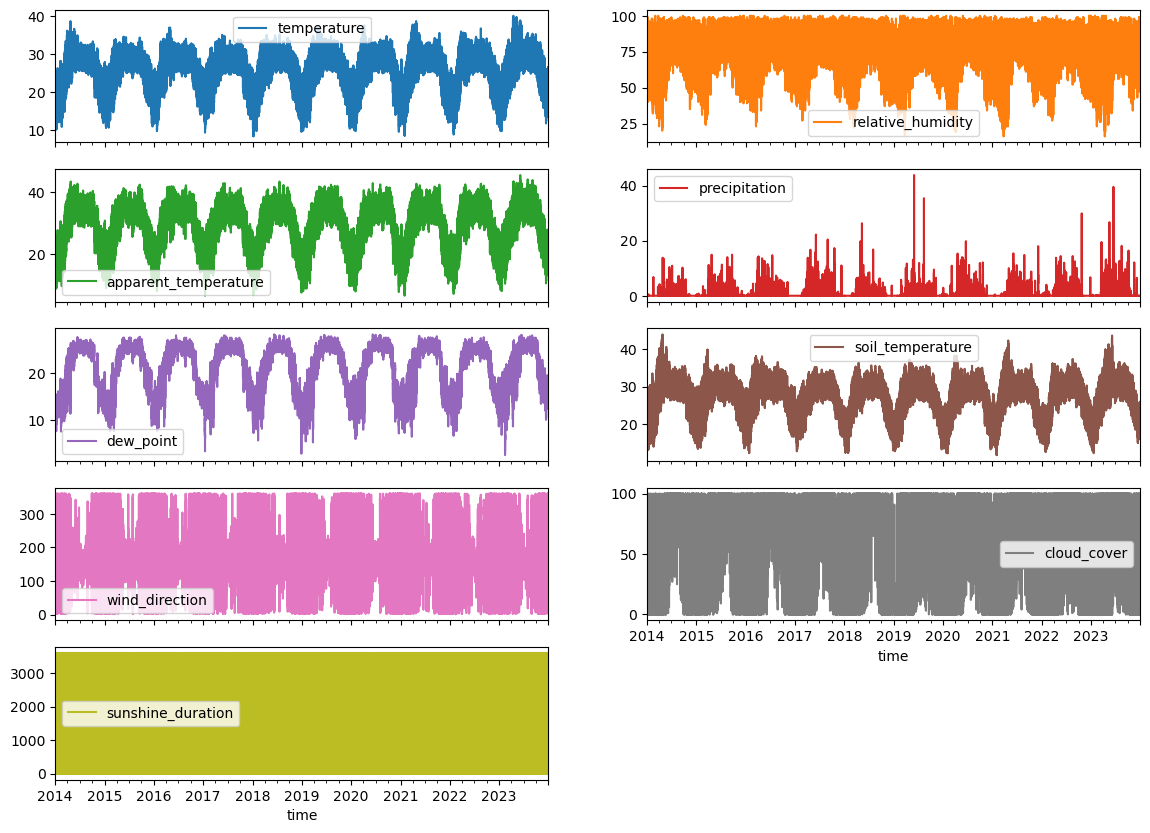

In [51]:
weather_df.set_index('time').plot(
    subplots=True,
    figsize=(14,10),
    layout=(len(weather_df.columns)//2, 2),
    sharex=True
)
plt.show()

<Axes: xlabel='time', ylabel='None'>

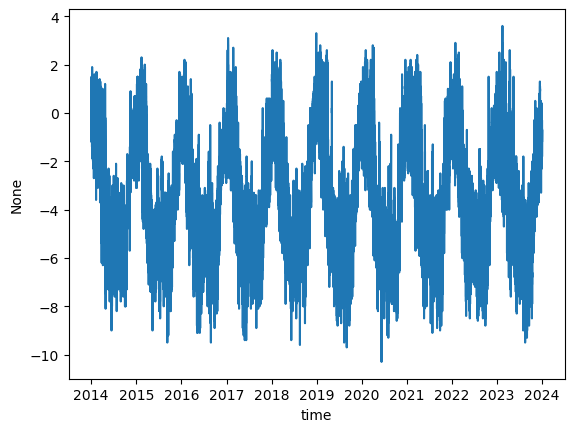

In [52]:
sns.lineplot(x=weather_df['time'],y = weather_df['temperature'] - weather_df['apparent_temperature'])

##### Basic Cleaning

In [53]:
weather_df['relative_humidity'] = weather_df['relative_humidity'].clip(0, 100)
weather_df['cloud_cover'] = weather_df['cloud_cover'].clip(0, 100)

weather_df.loc[weather_df['precipitation'] < 0, 'precipitation'] = 0

#wind
weather_df['wind_sin'] = np.sin(np.deg2rad(weather_df['wind_direction']))
weather_df['wind_cos'] = np.cos(np.deg2rad(weather_df['wind_direction']))

weather_df = weather_df.drop(columns=['wind_direction'])

w = 24

med = weather_df['precipitation'].rolling(w, min_periods=1).median().shift(1)
mad = (weather_df['precipitation'] - med).abs().rolling(w, min_periods=1).median().shift(1)

z = (weather_df['precipitation'] - med) / (mad + 1e-6)

precip_spikes = z.abs() > 5


,time,temperature,relative_humidity,apparent_temperature,precipitation,dew_point,soil_temperature,cloud_cover,sunshine_duration,wind_sin,wind_cos,precip_log
0,2014-01-01 00:00:00,13.9,89.0,13.3,0.0,12.1,16.4,0.0,0.0,-0.731354,0.681998,0.0
1,2014-01-01 01:00:00,13.6,91.0,13.2,0.0,12.1,16.0,0.0,0.0,-0.681998,0.731354,0.0
2,2014-01-01 02:00:00,13.3,91.0,12.8,0.0,11.9,15.7,0.0,0.0,-0.681998,0.731354,0.0
3,2014-01-01 03:00:00,13.0,92.0,12.5,0.0,11.8,15.4,0.0,0.0,-0.656059,0.754710,0.0
4,2014-01-01 04:00:00,12.7,93.0,12.2,0.0,11.6,15.2,0.0,0.0,-0.615661,0.788011,0.0


## Economic_Data Set

In [106]:
economic_df = economics_dataset.copy()

In [107]:
economic_df.head()

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service exports),TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (% of commercial service exports)",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [108]:
economic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516 entries, 0 to 1515
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1516 non-null   object 
 1   Indicator Name  1516 non-null   object 
 2   Indicator Code  1516 non-null   object 
 3   1960            176 non-null    float64
 4   1961            217 non-null    float64
 5   1962            210 non-null    float64
 6   1963            210 non-null    float64
 7   1964            210 non-null    float64
 8   1965            212 non-null    float64
 9   1966            210 non-null    float64
 10  1967            215 non-null    float64
 11  1968            215 non-null    float64
 12  1969            215 non-null    float64
 13  1970            295 non-null    float64
 14  1971            287 non-null    float64
 15  1972            348 non-null    float64
 16  1973            425 non-null    float64
 17  1974            424 non-null    f

In [109]:
economic_df['Country Name'].value_counts()

Country Name
X    1516
Name: count, dtype: int64

We don't need country name

### Indicator Filtering

In [110]:
economic_df = economic_df[economic_df['Indicator Code'].str.startswith(('EG','NY','NV','SP'))].reset_index()

In [111]:
economic_df.shape

(254, 70)

#### filtering EG

In [112]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
economic_df[economic_df['Indicator Code'].str.startswith('EG', na=False)][['Indicator Name', 'Indicator Code']]

,Indicator Name,Indicator Code
92,"Access to clean fuels and technologies for cooking, urban (% of urban population)",EG.CFT.ACCS.UR.ZS
120,"Energy use (kg of oil equivalent) per $1,000 GDP (constant 2021 PPP)",EG.USE.COMM.GD.PP.KD
121,GDP per unit of energy use (constant 2021 PPP $ per kg of oil equivalent),EG.GDP.PUSE.KO.PP.KD
122,"Electricity production from renewable sources, excluding hydroelectric (kWh)",EG.ELC.RNWX.KH
123,Electricity production from natural gas sources (% of total),EG.ELC.NGAS.ZS
124,Electricity production from coal sources (% of total),EG.ELC.COAL.ZS
125,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE
126,Fossil fuel energy consumption (% of total),EG.USE.COMM.FO.ZS
127,GDP per unit of energy use (PPP $ per kg of oil equivalent),EG.GDP.PUSE.KO.PP
128,Renewable electricity output (% of total electricity output),EG.ELC.RNEW.ZS


In [113]:
economic_df[economic_df['Indicator Code'].str.startswith('EG.ELC', na=False)][['Indicator Name', 'Indicator Code']]

,Indicator Name,Indicator Code
122,"Electricity production from renewable sources, excluding hydroelectric (kWh)",EG.ELC.RNWX.KH
123,Electricity production from natural gas sources (% of total),EG.ELC.NGAS.ZS
124,Electricity production from coal sources (% of total),EG.ELC.COAL.ZS
128,Renewable electricity output (% of total electricity output),EG.ELC.RNEW.ZS
129,Electric power transmission and distribution losses (% of output),EG.ELC.LOSS.ZS
130,Access to electricity (% of population),EG.ELC.ACCS.ZS
234,"Electricity production from renewable sources, excluding hydroelectric (% of total)",EG.ELC.RNWX.ZS
235,Electricity production from nuclear sources (% of total),EG.ELC.NUCL.ZS
236,"Electricity production from oil, gas and coal sources (% of total)",EG.ELC.FOSL.ZS
237,"Access to electricity, rural (% of rural population)",EG.ELC.ACCS.RU.ZS


In [114]:
keep_codes = [
    'EG.ELC.ACCS.ZS',      # overall
]

#### filtering NY

In [115]:
economic_df[economic_df['Indicator Code'].str.startswith('NY', na=False)][['Indicator Name', 'Indicator Code']]

,Indicator Name,Indicator Code
56,Adjusted savings: energy depletion (% of GNI),NY.ADJ.DNGY.GN.ZS
57,Adjusted savings: consumption of fixed capital (% of GNI),NY.ADJ.DKAP.GN.ZS
58,Adjusted savings: carbon dioxide damage (% of GNI),NY.ADJ.DCO2.GN.ZS
93,Terms of trade adjustment (constant LCU),NY.TTF.GNFS.KN
94,Taxes less subsidies on products (constant LCU),NY.TAX.NIND.KN
95,Net primary income (Net income from abroad) (current LCU),NY.GSR.NFCY.CN
96,Gross savings (current LCU),NY.GNS.ICTR.CN
97,GNI per capita (constant LCU),NY.GNP.PCAP.KN
98,"GNI per capita, Atlas method (current US$)",NY.GNP.PCAP.CD
99,GNI growth (annual %),NY.GNP.MKTP.KD.ZG


In [116]:
keep_codes += ['NY.GDP.MKTP.CD','NY.GDP.MKTP.KD.ZG']
keep_codes

['EG.ELC.ACCS.ZS', 'NY.GDP.MKTP.CD', 'NY.GDP.MKTP.KD.ZG']

#### filtering NV

In [117]:
economic_df[economic_df['Indicator Code'].str.startswith('NV', na=False)][['Indicator Name', 'Indicator Code']]

,Indicator Name,Indicator Code
49,Textiles and clothing (% of value added in manufacturing),NV.MNF.TXTL.ZS.UN
50,"Food, beverages and tobacco (% of value added in manufacturing)",NV.MNF.FBTO.ZS.UN
51,"Industry (including construction), value added (annual % growth)",NV.IND.TOTL.KD.ZG
52,"Manufacturing, value added (% of GDP)",NV.IND.MANF.ZS
53,"Manufacturing, value added (current LCU)",NV.IND.MANF.CN
54,Financial intermediary services indirectly Measured (FISIM) (current LCU),NV.FSM.TOTL.CN
55,"Agriculture, forestry, and fishing, value added (constant 2015 US$)",NV.AGR.TOTL.KD
59,"Services, value added (% of GDP)",NV.SRV.TOTL.ZS
60,"Services, value added (current LCU)",NV.SRV.TOTL.CN
61,Medium and high-tech manufacturing value added (% manufacturing value added),NV.MNF.TECH.ZS.UN


In [118]:
keep_codes += [
    'NV.IND.MANF.ZS',      # Manufacturing, value added (% of GDP)
    'NV.IND.MANF.KD.ZG'    # Manufacturing, value added (annual % growth)
]

#### filtering SP

In [119]:
economic_df[economic_df['Indicator Code'].str.startswith('SP', na=False)][['Indicator Name', 'Indicator Code']]

,Indicator Name,Indicator Code
0,Urban population,SP.URB.TOTL
1,Rural population,SP.RUR.TOTL
2,"Completeness of birth registration, rural (%)",SP.REG.BRTH.RU.ZS
3,"Population, male",SP.POP.TOTL.MA.IN
4,Technicians in R&D (per million people),SP.POP.TECH.RD.P6
5,"Age dependency ratio, old (% of working-age population)",SP.POP.DPND.OL
6,"Population ages 80 and above, female (% of female population)",SP.POP.80UP.FE.5Y
7,"Population ages 70-74, female (% of female population)",SP.POP.7074.FE.5Y
8,"Population ages 65 and above, male",SP.POP.65UP.MA.IN
9,"Population ages 65-69, female (% of female population)",SP.POP.6569.FE.5Y


In [120]:
keep_codes += [
    'SP.POP.TOTL',           # Population, total
    'SP.POP.GROW',           # Population growth (annual %)
]

In [121]:
keep_codes

['EG.ELC.ACCS.ZS',
 'NY.GDP.MKTP.CD',
 'NY.GDP.MKTP.KD.ZG',
 'NV.IND.MANF.ZS',
 'NV.IND.MANF.KD.ZG',
 'SP.POP.TOTL',
 'SP.POP.GROW']

In [124]:
economic_df = economic_df[economic_df['Indicator Code'].isin(keep_codes)].reset_index(drop=True)

In [125]:
economic_df

,index,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,243,X,Population growth (annual %),SP.POP.GROW,NaN,2.818718e+00,2.903941e+00,2.914868e+00,2.919516e+00,2.920485e+00,...,8.924324e-01,8.509173e-01,8.209552e-01,8.464113e-01,8.363108e-01,8.149780e-01,1.024234e+00,1.221715e+00,1.214621e+00,NaN
1,304,X,"Manufacturing, value added (% of GDP)",NV.IND.MANF.ZS,5.309911e+00,5.470589e+00,5.448665e+00,5.359331e+00,5.514049e+00,5.445474e+00,...,2.034795e+01,2.007506e+01,2.080230e+01,2.120794e+01,2.059833e+01,2.123567e+01,2.176482e+01,2.234202e+01,2.189296e+01,NaN
2,917,X,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.590000e+01,8.800000e+01,8.690000e+01,9.220000e+01,9.620000e+01,9.900000e+01,9.940000e+01,9.950000e+01,NaN,NaN
3,968,X,"Population, total",SP.POP.TOTL,5.182866e+07,5.331035e+07,5.488115e+07,5.650440e+07,5.817837e+07,5.990252e+07,...,1.608119e+08,1.621861e+08,1.635231e+08,1.649131e+08,1.662980e+08,1.676589e+08,1.693849e+08,1.714670e+08,1.735624e+08,NaN
4,1078,X,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,6.058161e+00,5.453031e+00,-4.558943e-01,1.095279e+01,1.606258e+00,...,7.113478e+00,6.590250e+00,7.319413e+00,7.881915e+00,3.448018e+00,6.938679e+00,7.099829e+00,5.775112e+00,4.223259e+00,NaN
5,1079,X,GDP (current US$),NY.GDP.MKTP.CD,4.274894e+09,4.817580e+09,5.081414e+09,5.319459e+09,5.386055e+09,5.906637e+09,...,2.652250e+11,2.937320e+11,3.213630e+11,3.512320e+11,3.739790e+11,4.162720e+11,4.601320e+11,4.374150e+11,4.501190e+11,NaN
6,1095,X,"Manufacturing, value added (annual % growth)",NV.IND.MANF.KD.ZG,NaN,8.229668e+00,7.004629e+00,5.469353e+00,4.940766e+00,4.280426e+00,...,1.169082e+01,7.086440e+00,1.045244e+01,1.233451e+01,1.680801e+00,1.158514e+01,1.141083e+01,8.894194e+00,3.156558e+00,NaN


#### Cleaning

In [126]:
year_cols = [str(y) for y in range(2015, 2025)]
keep_cols = ['Country Name', 'Indicator Name', 'Indicator Code'] + year_cols
economic_df = economic_df[keep_cols]

In [127]:
economic_cleaned = economic_df.set_index('Indicator Code')[year_cols].T
economic_cleaned.index.name = 'year'

In [128]:
economic_cleaned.head()

Indicator Code,SP.POP.GROW,NV.IND.MANF.ZS,EG.ELC.ACCS.ZS,SP.POP.TOTL,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.CD,NV.IND.MANF.KD.ZG
year,,,,,,,
2015,0.893819,16.788674,74.0,159383179.0,6.552640,1.951470e+11,10.310577
2016,0.892432,20.347948,75.9,160811932.0,7.113478,2.652250e+11,11.690815
2017,0.850917,20.075062,88.0,162186147.0,6.590250,2.937320e+11,7.086440
2018,0.820955,20.802296,86.9,163523103.0,7.319413,3.213630e+11,10.452442
2019,0.846411,21.207944,92.2,164913055.0,7.881915,3.512320e+11,12.334507


In [133]:
print(economic_cleaned.isnull().sum())

Country Name      0
Indicator Name    0
Indicator Code    0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
2022              0
2023              0
2024              0
dtype: int64


In [131]:
economic_cleaned = economic_df.ffill()

In [143]:
output_folder = ROOT / "data/processed"

economic_cleaned.to_csv(output_folder / "economic_cleaned_train.csv", index=False)